# Detection and Removal of outliers using Percentile method

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

### Loading and visualizing data

In [3]:
df = pd.read_csv('E:/Dataset/weight-height.csv')

In [5]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [6]:
df.shape

(10000, 3)

In [7]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


Text(0.5, 1.0, 'Weight')

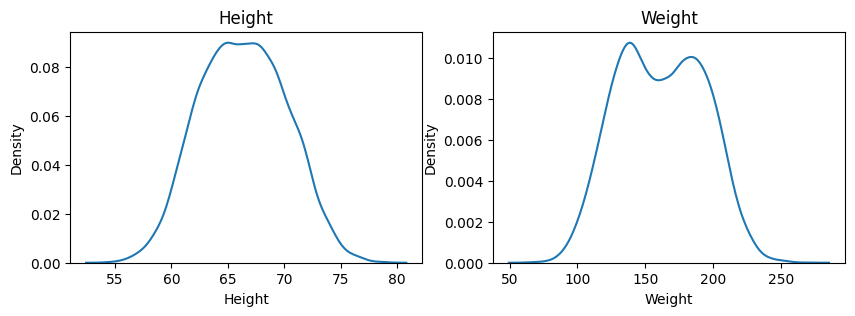

In [10]:
plt.figure(figsize=(10,3))
plt.subplot(121)
sns.kdeplot(df['Height'])
plt.title('Height')

plt.subplot(122)
sns.kdeplot(df['Weight'])
plt.title('Weight')

In [13]:
print(f'Skewness of height: {df['Height'].skew()}')
print(f'Skewness of weight: {df['Weight'].skew()}')

Skewness of height: 0.04936908937689042
Skewness of weight: 0.03295450444592442


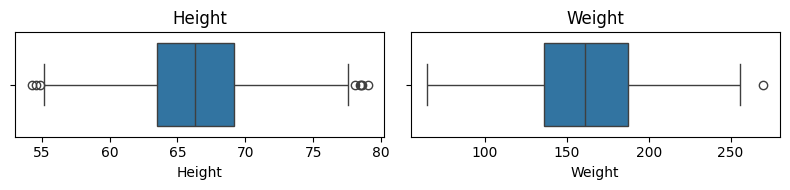

In [24]:
plt.figure(figsize=(8,2))
plt.subplot(121)
sns.boxplot(x=df['Height'])
plt.title('Height')

plt.subplot(122)
sns.boxplot(x=df['Weight'])
plt.title('Weight')

plt.tight_layout()

### Defining our percentile value and finding outliers

In [25]:
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)

print(f'Upper limit: {upper_limit}')
print(f'Lower limit: {lower_limit}')

Upper limit: 74.7857900583366
Lower limit: 58.13441158671655


In [27]:
# Finding outliers

outliers = df[(df['Height']>upper_limit) | (df['Height']<lower_limit)]

In [28]:
outliers.shape

(200, 3)

### Trimming

In [32]:
df.shape

(10000, 3)

In [29]:
new_df = df[(df['Height']<upper_limit) & (df['Height']>lower_limit)]

In [31]:
new_df.shape

(9800, 3)

#### Comparing after trimming

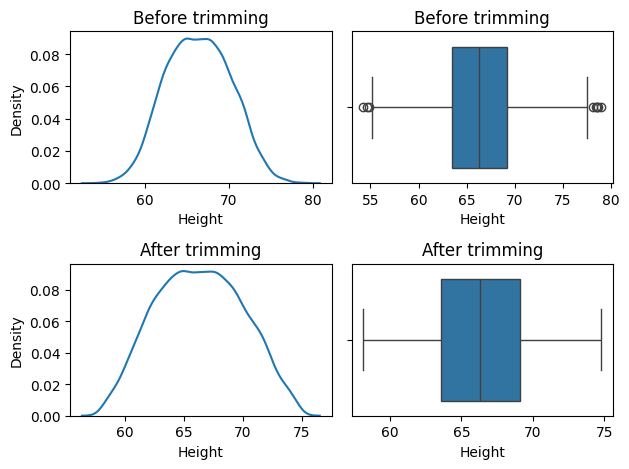

In [43]:
plt.subplot(221)
sns.kdeplot(df['Height'])
plt.title('Before trimming')

plt.subplot(222)
sns.boxplot(x=df['Height'])
plt.title('Before trimming')

plt.subplot(223)
sns.kdeplot(new_df['Height'])
plt.title('After trimming')

plt.subplot(224)
sns.boxplot(x=new_df['Height'])
plt.title('After trimming')

plt.tight_layout()
plt.show()

### Capping or Winsarization

In [33]:
df['capped_height'] = np.where(
    df['Height']>upper_limit,
    upper_limit,
    np.where(
        df['Height']<lower_limit,
        lower_limit,
        df['Height']
    )
)

In [35]:
df.sample(5)

,Gender,Height,Weight,capped_height
2693,Male,67.087552,176.417239,67.087552
634,Male,69.554762,192.181669,69.554762
9904,Female,57.028857,101.202551,58.134412
8141,Female,59.248656,110.587191,59.248656
722,Male,71.452327,203.448273,71.452327


In [40]:
df[['Height', 'capped_height']].describe()

,Height,capped_height
count,10000.000000,10000.000000
mean,66.367560,66.366281
std,3.847528,3.795717
min,54.263133,58.134412
25%,63.505620,63.505620
50%,66.318070,66.318070
75%,69.174262,69.174262
max,78.998742,74.785790


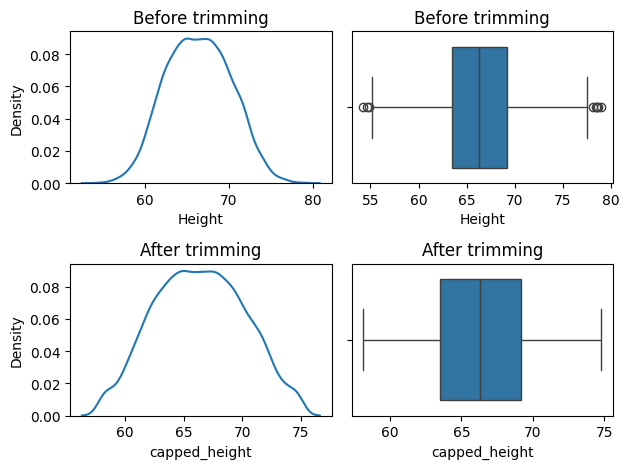

In [44]:
plt.subplot(221)
sns.kdeplot(df['Height'])
plt.title('Before trimming')

plt.subplot(222)
sns.boxplot(x=df['Height'])
plt.title('Before trimming')

plt.subplot(223)
sns.kdeplot(df['capped_height'])
plt.title('After trimming')

plt.subplot(224)
sns.boxplot(x=df['capped_height'])
plt.title('After trimming')

plt.tight_layout()
plt.show()